# Baseline C: Multimodal Learning (Image + Clinical Data)

This section implements a hybrid deep learning model combining image data and structured clinical features.

# Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import random

from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Reproducibility Configuration

In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Data Preparation: Merging Image and Clinical Data

In [ ]:
labels_df = pd.read_csv("processed_labels.csv")
clinical_df = pd.read_csv("aligned_clinical_dataset.csv")

# Extract patient_id
labels_df['patient_id'] = labels_df['image_id'].apply(lambda x: x.split('_')[0])

# Rename clinical ID
clinical_df.rename(columns={'ID': 'patient_id'}, inplace=True)

# Merge datasets
merged_df = pd.merge(labels_df, clinical_df, on='patient_id')

merged_df.head()

,image_id,label,patient_id,target,LeftRight,Age,Age_missing,Breast_density_encoded,BI_RADS,Mass_present,Calc_present
0,D1-0001_1-1.png,0,D1-0001,0,R,44.0,0.0,2.0,2.0,0.0,1.0
1,D1-0001_1-2.png,0,D1-0001,0,R,44.0,0.0,2.0,2.0,0.0,1.0
2,D1-0002_1-1.png,0,D1-0002,0,L,40.0,0.0,2.0,2.0,0.0,1.0
3,D1-0002_1-2.png,0,D1-0002,0,L,40.0,0.0,2.0,2.0,0.0,1.0
4,D1-0003_1-1.png,0,D1-0003,0,L,39.0,0.0,1.0,3.0,0.0,1.0


## Selecting Clinical Features

In [ ]:
clinical_features = [
    'Age',
    'Breast_density_encoded',
    'BI_RADS',
    'Mass_present',
    'Calc_present'
]

X_clinical = merged_df[clinical_features].fillna(0)

# Convert all clinical features to numeric
for col in clinical_features:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

# Fill missing values with 0
merged_df[clinical_features] = merged_df[clinical_features].fillna(0)

## Patient-Level Train-Test Split

In [ ]:
patient_ids = merged_df['patient_id'].unique()

train_ids, val_ids = train_test_split(
    patient_ids,
    test_size=0.3,
    random_state=42
)

train_df = merged_df[merged_df['patient_id'].isin(train_ids)]
val_df = merged_df[merged_df['patient_id'].isin(val_ids)]

## Copy Data from Drive

In [ ]:
!cp -r /content/drive/MyDrive/Processed_Images /content/
IMAGE_DIR = "/content/Processed_Images"

## Custom Dataset for Multimodal Input

In [ ]:
class MultimodalDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        img_path = os.path.join(IMAGE_DIR, row['image_id'])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        clinical = torch.tensor(
          row[clinical_features].values.astype(np.float32),
          dtype=torch.float
        )
        label = torch.tensor(row['label'], dtype=torch.long)

        return image, clinical, label

## Data Loaders & Sampler

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


train_dataset = MultimodalDataset(train_df, IMAGE_DIR, train_transform)
val_dataset = MultimodalDataset(val_df, IMAGE_DIR, val_transform)

y_train = train_df['label'].values

class_sample_count = torch.tensor([
    len(y_train[y_train == 0]),
    len(y_train[y_train == 1])
])

weights = 1. / class_sample_count.float()

samples_weight = torch.tensor(
    [weights[label] for label in y_train]
)

sampler = WeightedRandomSampler(
    samples_weight,
    len(samples_weight)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=0,
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    generator=torch.Generator().manual_seed(42)
)

## Hybrid Model Architecture

In [ ]:
class MultimodalModel(nn.Module):
    def __init__(self, num_clinical_features):
        super().__init__()

        # CNN backbone
        self.cnn = resnet18(weights=ResNet18_Weights.DEFAULT)
        for param in self.cnn.parameters():
          param.requires_grad = False
        for param in self.cnn.fc.parameters():
          param.requires_grad = True
        self.cnn.fc = nn.Identity()

        # Clinical branch
        self.fc_clinical = nn.Sequential(
          nn.Linear(num_clinical_features, 32),
          nn.ReLU()
      )

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, image, clinical):
        img_features = self.cnn(image)
        clinical_features = self.fc_clinical(clinical)

        combined = torch.cat((img_features, clinical_features), dim=1)
        return self.classifier(combined)

## Multimodal Training Function with Loss Tracking

In [ ]:
def train_model(model, train_loader, epochs=15):

    train_losses = []

    class_weights = torch.tensor([2.0, 1.0]).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.1
    )

    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, clinical, labels in train_loader:

            images = images.to(device)
            clinical = clinical.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images, clinical)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        train_losses.append(avg_loss)

        print(f"Epoch {epoch+1}, Loss: {avg_loss}")

    return model, train_losses

## Evaluation

In [ ]:
def evaluate_model(model, loader, threshold=0.45):

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, clinical, labels in loader:
            images = images.to(device)
            clinical = clinical.to(device)

            outputs = model(images, clinical)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = (probs >= threshold).long()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(y_true, y_pred))

## Model Training & Testing

In [ ]:
model = MultimodalModel(num_clinical_features=len(clinical_features)).to(device)

model, multimodal_losses = train_model(
    model,
    train_loader,
    epochs=20
)
evaluate_model(model, val_loader, threshold=0.25)

Epoch 1, Loss: 0.6546300387252932
Epoch 2, Loss: 0.634516093717969
Epoch 3, Loss: 0.6054742572748143
Epoch 4, Loss: 0.60533240178357
Epoch 5, Loss: 0.6000055408348208
Epoch 6, Loss: 0.5994692431843799
Epoch 7, Loss: 0.5967634517861449
Epoch 8, Loss: 0.5877714179780172
Epoch 9, Loss: 0.5774086318586183
Epoch 10, Loss: 0.5735780182092086
Epoch 11, Loss: 0.5719268195655035
Epoch 12, Loss: 0.5593659819468207
Epoch 13, Loss: 0.5755384823550349
Epoch 14, Loss: 0.5629680237692335
Epoch 15, Loss: 0.5628482219965562
Epoch 16, Loss: 0.5659099911218104
Epoch 17, Loss: 0.5595776072662809
Epoch 18, Loss: 0.5636742205723472
Epoch 19, Loss: 0.550313598435858
Epoch 20, Loss: 0.546746100096599
              precision    recall  f1-score   support

           0       0.29      0.35      0.31       120
           1       0.93      0.91      0.92      1114

    accuracy                           0.85      1234
   macro avg       0.61      0.63      0.62      1234
weighted avg       0.87      0.85      0.8

## Multimoal Training Loss Curve

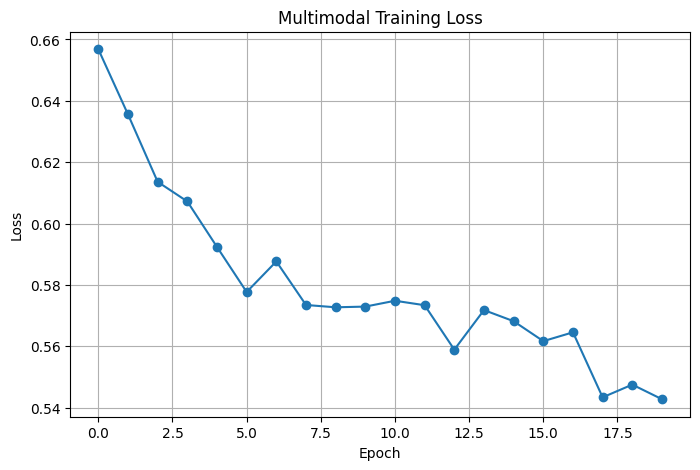

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(multimodal_losses, marker='o')

plt.title("Multimodal Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

## Multimodal Confusion Matrix Visualization

In [ ]:
def plot_confusion_matrix(model, loader, threshold=0.25):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, clinical, labels in loader:

            images = images.to(device)
            clinical = clinical.to(device)

            outputs = model(images, clinical)

            probs = torch.softmax(outputs, dim=1)[:,1]

            preds = (probs >= threshold).long()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

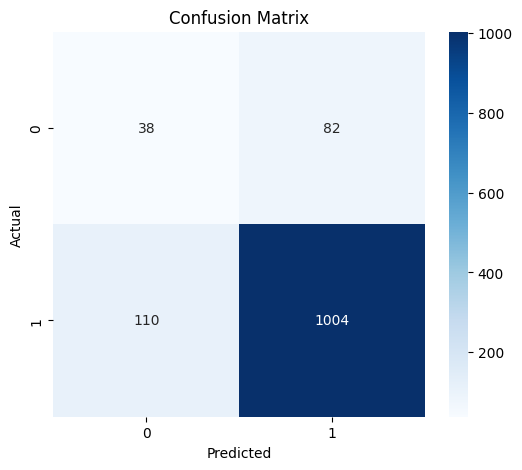

In [ ]:
plot_confusion_matrix(
    model,
    val_loader,
    threshold=0.25
)

## Multimodal ROC_Curve

In [ ]:
def plot_roc_curve(model, val_loader):

    model.eval()

    y_true = []
    y_scores = []

    with torch.no_grad():
        for images, clinical, labels in val_loader:

            images = images.to(device)
            clinical = clinical.to(device)

            outputs = model(images, clinical)

            probs = torch.softmax(outputs, dim=1)[:, 1]

            y_true.extend(labels.numpy())
            y_scores.extend(probs.cpu().numpy())

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, linewidth=2,
             label=f'AUC = {roc_auc:.2f}')

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multimodal ROC Curve")

    plt.legend()
    plt.grid(True)

    plt.show()

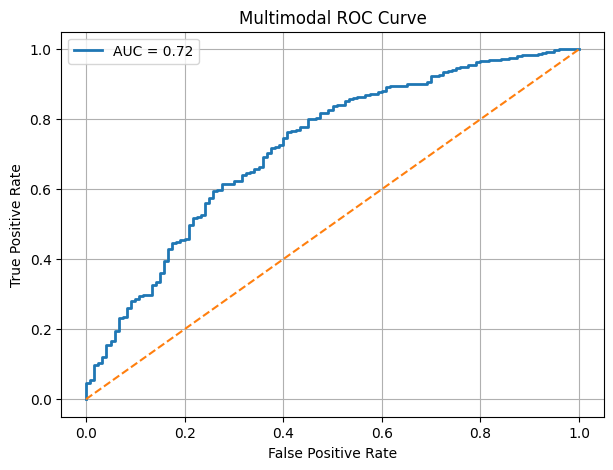

In [ ]:
plot_roc_curve(model, val_loader)

## Multimodal Performance Metrics

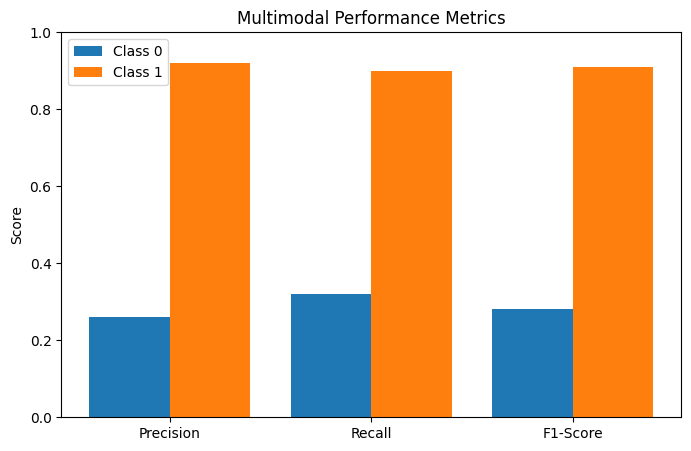

In [ ]:
metrics_names = ['Precision', 'Recall', 'F1-Score']

class_0 = [0.26, 0.32, 0.28]
class_1 = [0.92, 0.90, 0.91]

x = range(len(metrics_names))

plt.figure(figsize=(8,5))

plt.bar(x, class_0, width=0.4, label='Class 0')
plt.bar([i + 0.4 for i in x],
        class_1,
        width=0.4,
        label='Class 1')

plt.xticks([i + 0.2 for i in x], metrics_names)

plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("Multimodal Performance Metrics")

plt.legend()

plt.show()